# Temperature change in Larnaca, Cyprus

Use NOAA daily temperatures to calculate annual averages for 1978–2024, plot them, and fit a linear trend. All 47 years are included.

In [1]:
%matplotlib inline
import sys
import calendar
import hashlib
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import hvplot.pandas
from sklearn.linear_model import LinearRegression

print(f"Python {sys.version.split()[0]}: {sys.executable}")

Python 3.11.6: /opt/conda/bin/python


## Load the daily temperatures

Use the saved [NOAA GHCN-Daily file](https://www.ncei.noaa.gov/pub/data/ghcn/daily/all/CY000176090.dly) for Larnaca, station CY000176090. The download date and checksum are in data/cyprus_climate/source.json.

Temperatures are stored in tenths of °C: divide by 10. The value -9999 means a missing reading. TAVG averages hourly readings over a UTC day, unlike Boulder's observation-time TOBS. H identifies this averaging method; S identifies the source as NOAA's Global Summary of the Day. See [NOAA's definitions](https://www.ncei.noaa.gov/pub/data/ghcn/daily/readme.txt).

Every quality flag is blank (no failed NOAA checks), so the column adds nothing to this analysis. Check that once and drop it.

In [2]:
data_dir = Path("data/cyprus_climate")
source = json.loads((data_dir / "source.json").read_text())
raw = (data_dir / "CY000176090.dly").read_bytes()
assert hashlib.sha256(raw).hexdigest() == source["sha256"]

records = []
for line in raw.decode("ascii").splitlines():
    assert line[:11] == source["station"]
    if line[17:21] != "TAVG":
        continue
    year, month = int(line[11:15]), int(line[15:17])
    for day in range(1, calendar.monthrange(year, month)[1] + 1):
        start = 21 + (day - 1) * 8
        value = int(line[start:start + 5])
        mflag, qflag, sflag = line[start + 5:start + 8]
        valid = value != -9999
        records.append({"date": pd.Timestamp(year, month, day),
                        "temp_c": value / 10 if valid else float("nan"),
                        "measurement_flag": mflag.strip(),
                        "quality_flag": qflag.strip(),
                        "source_flag": sflag.strip()})

daily = pd.DataFrame(records).set_index("date").sort_index()
assert daily.index.is_unique
assert daily.quality_flag.eq("").all(), "Unexpected quality flag: review the source file."
daily = daily.drop(columns="quality_flag")
print("Valid record:", daily.temp_c.first_valid_index().date(),
      "to", daily.temp_c.last_valid_index().date())
print("First available readings in the raw file, before selecting 1978–2024:")
daily.loc[daily.temp_c.notna()].head()

Valid record: 1977-01-14 to 2025-08-24
First available readings in the raw file, before selecting 1978–2024:


,temp_c,measurement_flag,source_flag
date,,,
1977-01-14,9.3,H,S
1977-01-15,8.5,H,S
1977-01-22,10.3,H,S
1977-01-23,9.0,H,S
1977-01-28,10.4,H,S


In [3]:
# Reindex to calendar days so absent rows also count as missing.
calendar_days = pd.date_range("1978-01-01", "2024-12-31", name="date")
temperature = daily.temp_c.reindex(calendar_days)
print(f"1978–2024: {temperature.count():,} valid days / {len(temperature):,} calendar days")
print(f"Missing days: {temperature.isna().sum()}; coverage: {temperature.notna().mean():.3%}")
print("Flags on valid observations:")
display(daily.loc[temperature.dropna().index,
                  ["measurement_flag", "source_flag"]].value_counts())
assert temperature.count() == 17150
assert temperature.isna().sum() == 17

1978–2024: 17,150 valid days / 17,167 calendar days
Missing days: 17; coverage: 99.901%
Flags on valid observations:


measurement_flag  source_flag
H                 S              17150
Name: count, dtype: int64

## Check missing days

Use 1978–2024. The 1977 record has large gaps, and the file ends partway through 2025.

Keep all 47 years: only 17 of 17,167 daily readings are missing, and every year is at least 97.27% complete. List the gaps below. A few missing days are not a good reason to discard a whole year.

Each annual temperature is the mean of that year's available daily readings. Leave missing days unfilled.

In [4]:
monthly = temperature.resample("MS").agg(["mean", "count"])
monthly.columns = ["temp_c", "valid_days"]
monthly["expected_days"] = monthly.index.days_in_month
monthly["coverage"] = monthly.valid_days / monthly.expected_days
monthly["missing_days"] = monthly.expected_days - monthly.valid_days

display(monthly.loc[monthly.missing_days > 0,
                    ["valid_days", "expected_days", "missing_days", "coverage"]])

annual = temperature.resample("YS").agg(["mean", "count", "size"])
annual.columns = ["temp_c", "valid_days", "expected_days"]
annual["missing_days"] = annual.expected_days - annual.valid_days
annual["coverage_pct"] = 100 * annual.valid_days / annual.expected_days
annual["min_month_coverage"] = monthly.coverage.resample("YS").min()
annual.index = annual.index.year
annual.index.name = "year"

print(f"Main analysis: all {len(annual)} years, {annual.index.min()}–{annual.index.max()}.")
print(f"Annual coverage ranges from {annual.coverage_pct.min():.2f}% to {annual.coverage_pct.max():.2f}%.")
display(annual.loc[annual.missing_days > 0])
assert len(annual) == 47
assert annual.valid_days.sum() == 17150
annual.to_csv(data_dir / "larnaca-annual.csv", float_format="%.8f")

,valid_days,expected_days,missing_days,coverage
date,,,,
1979-04-01,29,30,1,0.966667
1992-02-01,28,29,1,0.965517
1993-12-01,30,31,1,0.967742
1999-01-01,30,31,1,0.967742
2021-02-01,25,28,3,0.892857
2024-03-01,27,31,4,0.870968
2024-08-01,30,31,1,0.967742
2024-11-01,26,30,4,0.866667
2024-12-01,30,31,1,0.967742


Main analysis: all 47 years, 1978–2024.
Annual coverage ranges from 97.27% to 100.00%.


,temp_c,valid_days,expected_days,missing_days,coverage_pct,min_month_coverage
year,,,,,,
1979,19.409890,364,365,1,99.726027,0.966667
1992,18.244110,365,366,1,99.726776,0.965517
1993,19.150549,364,365,1,99.726027,0.967742
1999,20.491758,364,365,1,99.726027,0.967742
2021,21.324033,362,365,3,99.178082,0.892857
2024,21.828652,356,366,10,97.267760,0.866667


2021 has **362/365 days (99.18%)** and 2024 has **356/366 days (97.27%)**. Both stay in the analysis. The monthly table shows where the gaps fall.

## Plot annual temperatures

Plot all 47 annual averages. Hover over the interactive points to see each year's coverage and missing days.

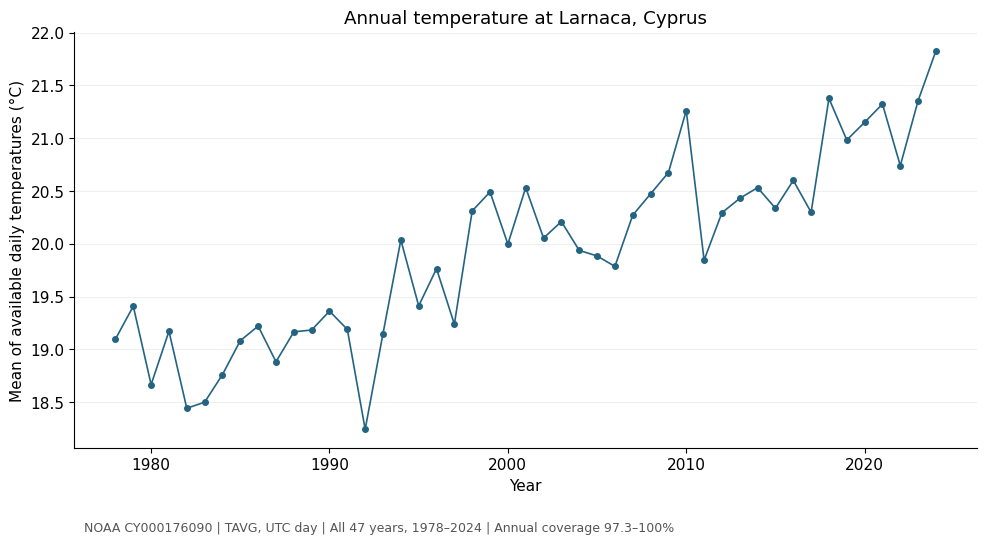

In [5]:
output_dir = Path("outputs/cyprus")
output_dir.mkdir(parents=True, exist_ok=True)
blue, red = "#246482", "#a33943"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(annual.index, annual.temp_c, color=blue, lw=1.2, marker="o", ms=4,
        label="Annual mean")
ax.set(title="Annual temperature at Larnaca, Cyprus", xlabel="Year",
       ylabel="Mean of available daily temperatures (°C)")
ax.grid(axis="y", alpha=0.2)
fig.text(0.09, 0.02,
         f"NOAA CY000176090 | TAVG, UTC day | All {len(annual)} years, 1978–2024 | Annual coverage {annual.coverage_pct.min():.1f}–100%",
         fontsize=9, color="#555555")
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(output_dir / "annual-temperature.png", dpi=180)
plt.show()

In [6]:
import hvplot

plot_data = annual.reset_index()
plot_data["min_month_pct"] = 100 * plot_data.min_month_coverage
hover_columns = ["valid_days", "missing_days", "coverage_pct", "min_month_pct"]
line = plot_data.hvplot.line(x="year", y="temp_c", color=blue, line_width=1, hover=False)
points = plot_data.hvplot.scatter(
    x="year", y="temp_c", color=blue, size=45,
    hover_cols=hover_columns, label="Annual mean: all 47 years")
interactive = (line * points).opts(
    title="Larnaca annual temperature | NOAA CY000176090 | 1978–2024",
    xlabel="Year", ylabel="Annual mean temperature (°C)",
    width=900, height=440, legend_position="top_left")
hvplot.save(interactive, str(output_dir / "annual-temperature.html"), resources="inline")
interactive

:Overlay
   .Curve.I                                :Curve   [year]   (temp_c)
   .Scatter.Annual_mean_colon_all_47_years :Scatter   [year]   (temp_c,valid_days,missing_days,coverage_pct,min_month_pct)

## Fit a linear trend

Fit a straight line to annual temperature using scikit-learn's ordinary least squares regression. Give each year equal weight. Multiply the yearly slope by 10 to get °C per decade.

The fitted change compares the line's endpoints, rather than the observed temperatures in the first and last years.

In [7]:
def fit_trend(frame):
    x = frame.index.to_numpy().reshape(-1, 1)
    model = LinearRegression().fit(x, frame.temp_c)
    return model, float(model.coef_[0] * 10), float(model.score(x, frame.temp_c))

model, slope_decade, r_squared = fit_trend(annual)
fit_years = pd.DataFrame({"year": range(annual.index.min(), annual.index.max() + 1)})
fit_years["fit_c"] = model.predict(fit_years[["year"]].to_numpy())
summary = {
    "station": source["station"], "first_year": int(annual.index.min()),
    "last_year": int(annual.index.max()), "annual_observations": len(annual),
    "selection": "All years in 1978–2024; missing daily readings omitted",
    "excluded_candidate_years": [], "valid_days": int(annual.valid_days.sum()),
    "missing_days": int(annual.missing_days.sum()),
    "slope_c_per_decade": slope_decade, "r_squared": r_squared,
    "fitted_change_c": slope_decade / 10 * (annual.index.max() - annual.index.min())}
print(f"OLS trend: {slope_decade:+.3f} °C/decade; R² = {r_squared:.3f}")
print(f"Fitted change, {summary['first_year']}–{summary['last_year']}: {summary['fitted_change_c']:.2f} °C")
(output_dir / "trend-summary.json").write_text(json.dumps(summary, indent=2))

OLS trend: +0.568 °C/decade; R² = 0.788
Fitted change, 1978–2024: 2.61 °C


378

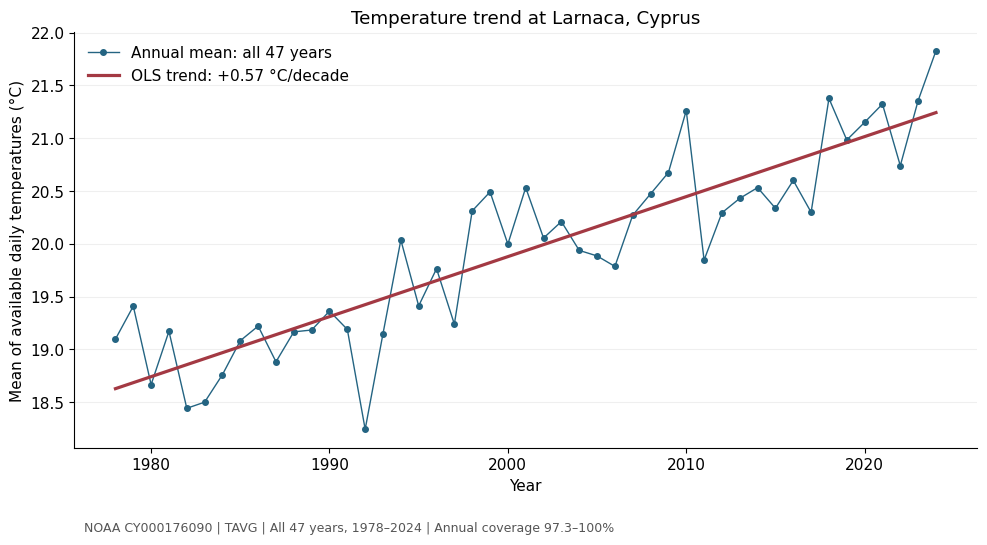

:Overlay
   .Curve.I                                                  :Curve   [year]   (temp_c)
   .Scatter.Annual_mean_colon_all_47_years                   :Scatter   [year]   (temp_c,valid_days,missing_days,coverage_pct,min_month_pct)
   .Curve.OLS_colon_plus_0_full_stop_57_degree_C_over_decade :Curve   [year]   (fit_c)

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(annual.index, annual.temp_c, color=blue, marker="o", ms=4, lw=1,
        label="Annual mean: all 47 years")
ax.plot(fit_years.year, fit_years.fit_c, color=red, lw=2.3,
        label=f"OLS trend: {slope_decade:+.2f} °C/decade")
ax.set(title="Temperature trend at Larnaca, Cyprus", xlabel="Year",
       ylabel="Mean of available daily temperatures (°C)")
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, loc="upper left")
fig.text(0.09, 0.02,
         f"NOAA CY000176090 | TAVG | All {len(annual)} years, 1978–2024 | Annual coverage {annual.coverage_pct.min():.1f}–100%",
         fontsize=9, color="#555555")
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(output_dir / "temperature-trend.png", dpi=180)
plt.show()

trend_line = fit_years.hvplot.line(x="year", y="fit_c", color=red, hover=False,
                                 line_width=2, label=f"OLS: {slope_decade:+.2f} °C/decade")
interactive_trend = (interactive * trend_line).opts(
    xlabel="Year", ylabel="Annual mean temperature (°C)",
    width=900, height=440, legend_position="top_left",
    title=f"Larnaca temperature trend | {slope_decade:+.2f} °C/decade | n={len(annual)}")
hvplot.save(interactive_trend, str(output_dir / "temperature-trend.html"), resources="inline")
interactive_trend

## Check whether the choices matter

Compare the main trend with fits that require 80%, 90%, or 100% coverage in every month. These rules drop years; stricter does not automatically mean more accurate. Also try starting in 1988 and 1998.

Missing days can change how much each season contributes to an annual average. Check this by averaging the monthly means, weighted by each month's calendar days. This checks seasonal weighting without estimating the missing daily temperatures.

In [9]:
scenarios = [("main: all years", 1978, None), ("80% monthly", 1978, 0.80),
             ("90% monthly", 1978, 0.90), ("complete months", 1978, 1.00),
             ("start 1988, all years", 1988, None), ("start 1998, all years", 1998, None)]
checks = []
for label, start_year, threshold in scenarios:
    sample = annual.loc[annual.index >= start_year]
    if threshold is not None:
        sample = sample.loc[sample.min_month_coverage >= threshold]
    _, slope, score = fit_trend(sample)
    checks.append({"case": label, "first_year": sample.index.min(),
                   "last_year": sample.index.max(), "n_years": len(sample),
                   "slope_c_per_decade": slope, "r_squared": score})
sensitivity = pd.DataFrame(checks).set_index("case")
display(sensitivity.round(3))
sensitivity.to_csv(output_dir / "trend-sensitivity.csv", float_format="%.8f")

balanced = (monthly.temp_c * monthly.expected_days).resample("YS").sum() / monthly.expected_days.resample("YS").sum()
balanced.index = balanced.index.year
balanced_sample = annual.copy()
balanced_sample["temp_c"] = balanced.reindex(annual.index)
_, balanced_slope, _ = fit_trend(balanced_sample)
print(f"Monthly calendar weighting, all 47 years: {balanced_slope:+.3f} °C/decade")
print(f"Difference from main slope: {balanced_slope - slope_decade:+.4f} °C/decade")

,first_year,last_year,n_years,slope_c_per_decade,r_squared
case,,,,,
main: all years,1978,2024,47,0.568,0.788
80% monthly,1978,2024,47,0.568,0.788
90% monthly,1978,2023,45,0.543,0.763
complete months,1978,2023,41,0.548,0.823
"start 1988, all years",1988,2024,37,0.604,0.717
"start 1998, all years",1998,2024,27,0.475,0.489


Monthly calendar weighting, all 47 years: +0.565 °C/decade
Difference from main slope: -0.0035 °C/decade


## What this tells us

The trend describes this Larnaca station over 1978–2024. It does not establish the cause of the change or represent all of Cyprus. Station moves, equipment changes and local development could affect the record; checking those needs station history and nearby records. The fitted line is not a forecast.

To rerun: open the notebook at the repository root, select base Python 3.11.6, and Run All. Inputs are in data/cyprus_climate; results go to outputs/cyprus. Package versions are recorded below.

In [10]:
from importlib.metadata import version

packages = ["pandas", "numpy", "matplotlib", "scikit-learn", "hvplot",
            "holoviews", "bokeh", "panel", "ipykernel", "nbformat", "nbclient"]
versions = {name: version(name) for name in packages}
(output_dir / "environment.json").write_text(
    json.dumps({"python": sys.version.split()[0], "packages": versions}, indent=2))
pd.Series(versions, name="version")

pandas           2.3.2
numpy            2.2.6
matplotlib      3.10.6
scikit-learn     1.7.2
hvplot          0.12.1
holoviews       1.19.0
bokeh            3.8.0
panel            1.8.0
ipykernel       6.30.1
nbformat        5.10.4
nbclient        0.10.2
Name: version, dtype: object